# Option analytics: conditioning one forecast on another

[`06_linear`](06_linear.ipynb) made the point that separates this case study from every other one
in the book. Its features are not a record of what happened to each stock - they are what the
options market was willing to pay for a claim on what happens next. Implied volatility, the skew
between puts and calls, the slope of the term structure, the gap between implied and realized
variance: each is already a forecast, made by people with money at stake.

A penalized linear model asks whether a weighted sum of those forecasts ranks the cross-section.
Gradient boosting asks a different question, and on a volatility surface it is the more natural
one. A tree splits on one feature inside a region defined by another, so it can express "read the
skew one way when the term structure slopes upward, and another way when it is inverted" - a
conditional statement, which is how practitioners actually read a surface. The linear model can
only see that if someone multiplies the columns together first.

Three dials control how far the model goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how finely one tree may partition the feature space, and so
  how many such conditions it can express at once.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Five-day equity
  returns have tails, and the metric here is a rank correlation, so the two do not want the same
  thing from a fit.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run. Fifteen
  declared configurations at ten checkpoints is 150 candidate models, and **a checkpoint is part
  of a configuration rather than a detail of how it was fitted.**

Two folds, one of which validates on 2020. The usable history of this option analytics dataset is
short, so the walk-forward schedule `05_evaluation` set has few and wide windows, and 150
candidates judged on two of them is the arithmetic to keep in view while reading the table.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what a tree ensemble can represent that a penalized linear model cannot, in terms of the
  volatility surface rather than in the abstract.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Judge whether a model built on features that are themselves forecasts adds anything to them.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`14_backtest`](14_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared option-analytics gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

In [3]:
study = open_study(
    "sp500_equity_option_analytics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

The label is the same one the linear notebook used: `fwd_ret_5d`, the stock's total return over
the five trading days after the decision date. Keeping it fixed is what makes the two
populations comparable - the families differ, the target does not.

In [4]:
declared_labels(study, "gbm")

('fwd_dir_10d',
 'fwd_dir_5d',
 'fwd_ret_10d',
 'fwd_ret_5d',
 'fwd_ret_risk_adj_5d')

The menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`, and each
resolves to a preset in `case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. Here that decides whether a model can express a condition on the surface -
  read the skew one way when the term structure slopes upward and another way when it does
  not - which is the natural shape for an options-derived signal and one a linear model cannot
  take unless someone builds the interaction column first.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_dir_10d""","""default_binary""","""""","""objective=binary, seed=42"""
"""gbm""","""fwd_dir_10d""","""leaves_7_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_15_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_31_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_10d""","""leaves_63_binary""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_risk_adj_5d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. Comparing the loaded rows against the complete declared catalog catches
either knob, and says so here rather than several cells later in a message about hashes.

In [6]:
if configs.height < load_model_configs(study, "gbm").height and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared configurations, so it cannot publish "
        "the canonical population; pass POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_15_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_31_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_63_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
"""leaves_7_binary""",48,547,192139,2,10,2019-01-07,2020-12-16
…,…,…,…,…,…,…,…
"""leaves_63_mae""",48,549,194748,2,10,2019-01-07,2020-12-23
"""leaves_63_mse""",48,549,194748,2,10,2019-01-07,2020-12-23
"""leaves_7_huber""",48,549,194748,2,10,2019-01-07,2020-12-23


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [8]:
population_name = POPULATION_NAME or "sp500_equity_option_analytics-gbm-validation-v1"
execution, population = run_model_population(
    study, resolved, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 0: training n_train=192,800 n_val=93,351 trees=500 num_leaves=? obj=binary


      fold 0: done in 17s


      fold 1: training n_train=181,243 n_val=98,788 trees=500 num_leaves=? obj=binary


      fold 1: done in 3s


      fold 0: training n_train=192,800 n_val=93,351 trees=500 num_leaves=7 obj=binary


...

      fold 0: training n_train=195,429 n_val=95,892 trees=500 num_leaves=63 obj=huber


      fold 0: done in 5s


      fold 1: training n_train=183,903 n_val=98,856 trees=500 num_leaves=63 obj=huber


      fold 1: done in 4s


55 configurations fitted
population sp500_equity_option_analytics-gbm-validation-v1: 550 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_5d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the stocks by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

550 candidate models: 20 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""leaves_7_mse""",100,0.012633,0.004201,492.0,false
"""leaves_7_mse""",150,0.01166,0.002943,492.0,false
"""leaves_7_mse""",350,0.011407,0.005488,492.0,false
"""leaves_15_mse""",100,0.011011,0.006182,492.0,false
"""leaves_7_mse""",200,0.010936,0.003404,492.0,false
…,…,…,…,…,…
"""leaves_7_mse""",400,0.010142,0.006045,492.0,false
"""leaves_7_mse""",250,0.009909,0.003713,492.0,false
"""leaves_7_mse""",50,0.00983,0.002348,492.0,false


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

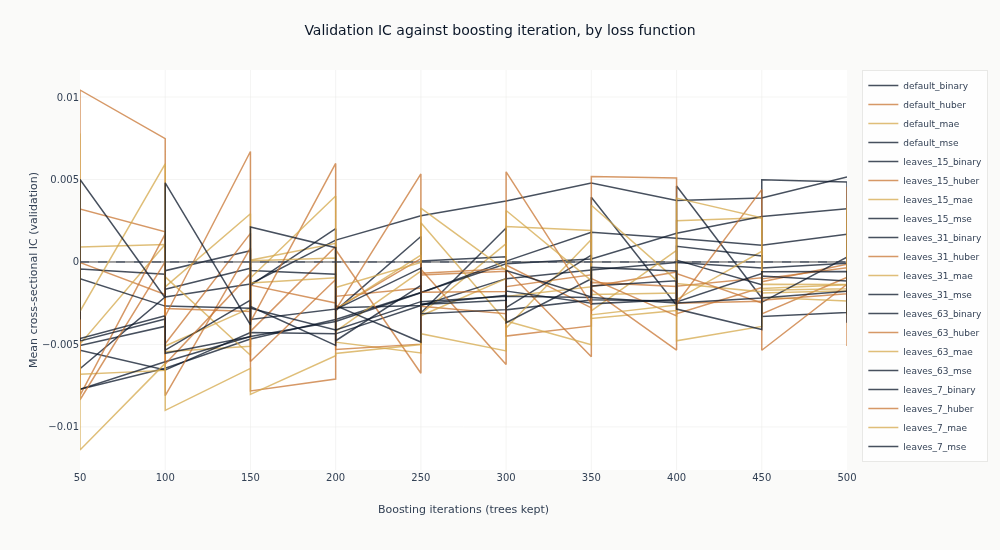

In [10]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. The lines sit in a narrow band just below "
    "it, and the three colours are mixed through the band rather than separated into layers. They "
    "wander up and down without rising to a common peak and falling away.",
)

### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

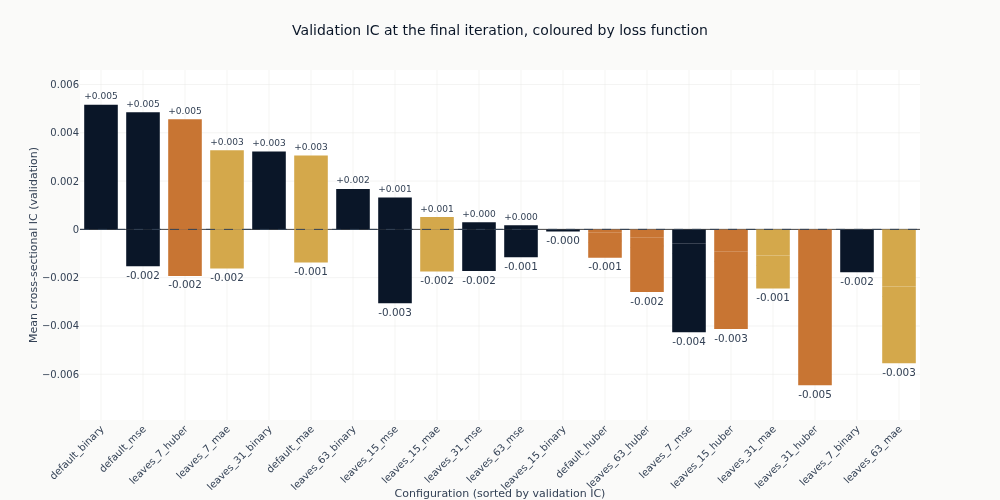

In [11]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. Almost every bar hangs just below the line and the bars are of similar "
    "length. The three colours are interleaved across the ranking rather than grouped, so neither "
    "the loss function nor the leaf count orders the configurations.",
)

### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [12]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0103
median IC range within one configuration: 0.0092


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_7_huber""",-0.003633,0.010425,-0.001932,0.014058
"""leaves_31_huber""",-0.008105,0.004783,-0.001355,0.012888
"""default_binary""",-0.006472,0.005159,0.005159,0.011632
"""leaves_31_binary""",-0.007722,0.003229,0.003229,0.010952
"""leaves_7_mae""",-0.002988,0.007792,-0.001623,0.01078
…,…,…,…,…
"""leaves_63_mse""",-0.005538,0.000168,-0.001152,0.005707
"""leaves_31_mse""",-0.005347,0.000297,0.000297,0.005645
"""leaves_15_mse""",-0.0033,0.001325,-0.003059,0.004625


## 5. What to notice

**Conditioning does not add anything here.** The whole reason to bring a tree ensemble to a
volatility surface is that reading one part of it conditional on another is how the surface is
actually used. Every configuration in this grid ends training at or below zero, in a band
narrower than a single percentage point of rank correlation, and the linear notebook's penalty
sweep reached the same place. Two model classes with different representational power arrive at
the same answer on the same rows, which points at the target rather than at either model.

**The loss function does not separate the results, and that is worth stating.** In case studies
whose labels have heavy tails the three objectives order themselves consistently - Huber, then
absolute error, then squared error - because squared error spends the fit on extremes a rank
metric does not reward. Here the three medians land on top of one another. That is the control
working: this label is a five-day equity return, whose tails are mild next to a short straddle's
or a perpetual's, and where the tails are mild the choice of objective stops mattering. A reader
who took "always prefer Huber" from another notebook in this book should take this one as the
boundary of that rule.

**Most configurations are still improving when training stops.** Nearly half reach their highest
IC at the last checkpoint rather than at an interior one. Read on its own that would suggest a
longer schedule; read against the level, it says the curves are drifting inside a band around
zero and the last checkpoint is where the drift happened to be. An interior optimum means
something when there is something to optimize.

**The features being forecasts is what makes the null informative.** Elsewhere a weak result
invites the question of whether the features carry information. That question is already
answered here: implied volatility, skew and the variance risk premium are priced by people with
money at stake, and they demonstrably forecast something. What this notebook establishes is that
what they forecast is not the five-day cross-sectional ranking of the underlying stock's return.
The natural next question is what they do forecast, and the case study's other labels -
risk-adjusted return and direction - exist to ask it.

**The sample is two folds, one of them 2020.** Every number above is an average over two
validation windows of a short dataset, one covering a year in which the option surface behaved
unlike any other in the sample. That is enough to say the effect is not large; it is not enough
to characterise it.

**None of this selects anything.** IC measures whether predictions rank stocks correctly, not
whether a strategy trading them makes money after costs and turnover. Selection is on validation
backtest Sharpe over the population just published, in [`14_backtest`](14_backtest.ipynb), where
the checkpoint is part of what is selected.

**Known limitations.** Two folds. The IC is an average of daily rank correlations with no
adjustment for the serial dependence overlapping five-day returns create, so it is a diagnostic
rather than a test. The grid varies capacity and loss at a fixed learning rate. And every number
is measured on validation folds already read many times by the time a case study reaches this
notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) fits a neural network to the same rows, and
[`11_latent_factors`](11_latent_factors.ipynb) asks whether the surface has structure that a
supervised model is the wrong instrument for. Given that two supervised families have now agreed,
the latent-factor route is the more interesting of the two.